# Clasificador de Imágenes — CIFAR-10
**TP Grupal — Procesamiento de Aprendizaje Automático**

Integrantes: *(completar apellidos/nombres)*  
Carrera: *(completar)*  
IFTS Nro: *(completar)*

---

### Decisiones del grupo

Se optó por **modificar el código original** para obtener mejores predicciones. Las mejoras aplicadas son:

| Parámetro | Original | Modificado | Justificación |
|---|---|---|---|
| Filtros 2da Conv2D | 32 | 64 | Mayor capacidad para extraer features complejas |
| Neuronas capa Dense | 64 | 128 | Representación más rica antes de clasificar |
| Dropout | ❌ | 0.4 | Regularización: reduce overfitting |
| Activación final | logits | softmax | Salida en probabilidades reales (0–1) |
| Epochs | 3 | 20 | 3 epochs es insuficiente para CIFAR-10 |
| Learning rate | default | 0.001 | Control explícito del paso de optimización |
| Batch size | 64 | 64 | Se mantiene |
| Data Augmentation | ❌ | ✅ | Variaciones artificiales mejoran generalización |

El modelo entrenado se exporta en formato **TensorFlow.js** para ser usado desde una interfaz web en JavaScript.

## 1. Instalación de dependencias

In [1]:
# Instalamos tensorflowjs para poder convertir el modelo al formato que usa el browser
!pip install tensorflowjs --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.6.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
bigquery-magics 0.14.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.41.0 requires packaging>=24.2.0, but you have packaging 2

## 2. Importación de librerías

In [2]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.19.0
GPU disponible: True


## 3. Carga y preprocesamiento del dataset

CIFAR-10 contiene **60.000 imágenes** de 32×32 píxeles en color (3 canales RGB), distribuidas en 10 clases:
- 50.000 para entrenamiento
- 10.000 para verificación

La **normalización** divide cada valor de píxel (0–255) por 255, dejando todos los valores entre 0 y 1. Esto acelera el entrenamiento y mejora la convergencia del optimizador.

In [3]:
(imagenes_entrenamiento, etiquetas_entrenamiento), (imagenes_verificacion, etiquetas_verificacion) = \
    keras.datasets.cifar10.load_data()

print('Forma del conjunto de entrenamiento:', imagenes_entrenamiento.shape)
print('Forma del conjunto de verificación: ', imagenes_verificacion.shape)

# Normalización entre 0 y 1
imagenes_entrenamiento = imagenes_entrenamiento / 255.0
imagenes_verificacion  = imagenes_verificacion  / 255.0

# Nombres de las 10 clases
nombres_clases = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                  'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Forma del conjunto de entrenamiento: (50000, 32, 32, 3)
Forma del conjunto de verificación:  (10000, 32, 32, 3)


## 4. Visualización de ejemplos del dataset

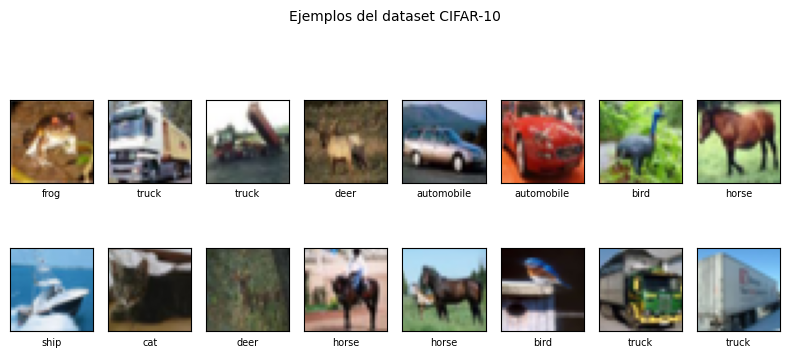

In [4]:
def mostrar():
    plt.figure(figsize=(8, 4))
    for i in range(16):
        plt.subplot(2, 8, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(imagenes_entrenamiento[i])
        plt.xlabel(nombres_clases[etiquetas_entrenamiento[i][0]], fontsize=7)
    plt.suptitle('Ejemplos del dataset CIFAR-10', fontsize=10)
    plt.tight_layout()
    plt.show()

mostrar()

## 5. Data Augmentation (MEJORA AGREGADA)

El **data augmentation** genera variaciones artificiales de las imágenes de entrenamiento (rotaciones, flips, zoom). Esto expone al modelo a más casos posibles y reduce el overfitting, mejorando la capacidad de generalización.

Se aplica **solo al conjunto de entrenamiento**, nunca al de verificación.

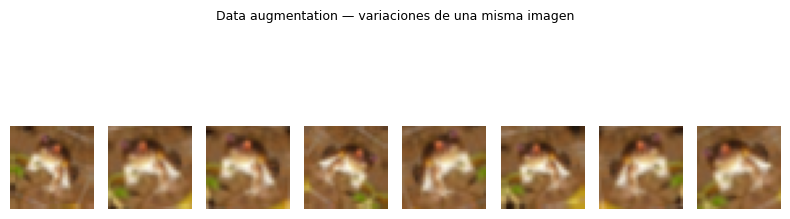

In [5]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
], name='data_augmentation')

# Visualizar efecto del augmentation
plt.figure(figsize=(8, 3))
imagen_ejemplo = imagenes_entrenamiento[0:1]
for i in range(8):
    ax = plt.subplot(1, 8, i + 1)
    img_aug = data_augmentation(imagen_ejemplo, training=True)
    plt.imshow(img_aug[0])
    plt.axis('off')
plt.suptitle('Data augmentation — variaciones de una misma imagen', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Definición del modelo mejorado

**Arquitectura:**
- **Data augmentation** integrado al modelo
- **2 bloques Conv2D → MaxPooling** para extracción jerárquica de features
  - 1er bloque: 32 filtros — detecta bordes, texturas simples
  - 2do bloque: 64 filtros — detecta formas y patrones más complejos
- **Flatten** para aplanar el tensor 3D a 1D
- **Dense(128, relu)** — capa de clasificación intermedia
- **Dropout(0.4)** — desactiva el 40% de neuronas al azar durante el entrenamiento (regularización)
- **Dense(10, softmax)** — salida: probabilidades para cada una de las 10 clases

In [6]:
capa = keras.layers

modelo = keras.models.Sequential([
    # Augmentation (solo activo durante entrenamiento)
    data_augmentation,

    # Bloque convolucional 1 — igual que el original
    capa.Conv2D(32, (3, 3), strides=(1, 1), padding='valid',
                activation='relu', input_shape=(32, 32, 3)),
    capa.MaxPool2D(2, 2),

    # Bloque convolucional 2 — 64 filtros en lugar de 32 (MEJORA)
    capa.Conv2D(64, 3, activation='relu'),
    capa.MaxPool2D(2, 2),

    capa.Flatten(),

    # Capa densa 128 neuronas en lugar de 64 (MEJORA)
    capa.Dense(128, activation='relu'),

    # Dropout para regularización (MEJORA)
    capa.Dropout(0.4),

    # Salida con softmax — produce probabilidades reales (MEJORA vs logits)
    capa.Dense(10, activation='softmax')
])

modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (1, 32, 32, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 30, 30, 32)        │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 15, 15, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 13, 13, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 6, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 2304)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 10)                │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Compilación del modelo

- **Optimizador Adam** con learning rate 0.001 explícito: algoritmo adaptativo, converge más rápido que SGD
- **Loss: SparseCategoricalCrossentropy** — función de pérdida estándar para clasificación multiclase con etiquetas enteras
- **Métrica: accuracy** — proporción de predicciones correctas

In [7]:
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

## 8. Entrenamiento

Se entrena con **20 epochs** (el original usaba 3 — insuficiente para CIFAR-10).

Se usa `EarlyStopping` como callback: si el `val_accuracy` no mejora en 5 epochs seguidas, el entrenamiento se detiene automáticamente y se restauran los mejores pesos. Evita overfitting y desperdicio de tiempo.

In [8]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

historial = modelo.fit(
    imagenes_entrenamiento,
    etiquetas_entrenamiento,
    epochs=20,
    batch_size=64,
    validation_data=(imagenes_verificacion, etiquetas_verificacion),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3761 - loss: 1.7187 - val_accuracy: 0.4956 - val_loss: 1.4023
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4746 - loss: 1.4627 - val_accuracy: 0.5340 - val_loss: 1.2876
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5093 - loss: 1.3729 - val_accuracy: 0.5769 - val_loss: 1.1880
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5337 - loss: 1.3101 - val_accuracy: 0.5958 - val_loss: 1.1380
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5517 - loss: 1.2667 - val_accuracy: 0.6225 - val_loss: 1.0662
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5630 - loss: 1.2395 - val_accuracy: 0.6292 - val_loss: 1.0497
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5724 - loss: 1.2107 - val_accuracy: 0.6296 - val_loss: 1.0559
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5819 - loss: 1.1837 - val_accuracy: 

## 9. Evaluación del modelo

In [9]:
loss, accuracy = modelo.evaluate(imagenes_verificacion, etiquetas_verificacion,
                                  batch_size=64, verbose=0)
print(f'Loss final:    {loss:.4f}')
print(f'Accuracy final: {accuracy:.4f} ({accuracy*100:.1f}%)')

Loss final:    0.9189
Accuracy final: 0.6819 (68.2%)


## 10. Curvas de entrenamiento

Visualizamos cómo evolucionó el **accuracy** y el **loss** a lo largo de los epochs, tanto para entrenamiento como para validación. Una brecha grande entre ambas curvas indica overfitting.

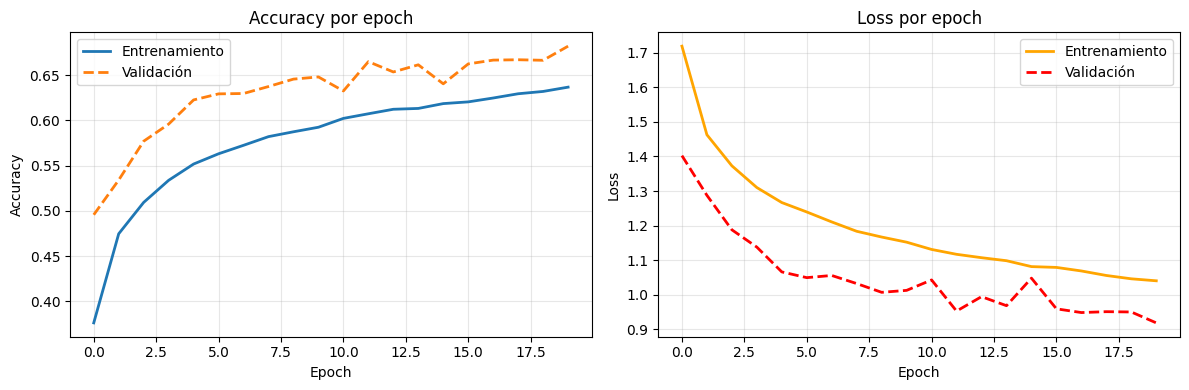

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(historial.history['accuracy'],     label='Entrenamiento', linewidth=2)
ax1.plot(historial.history['val_accuracy'], label='Validación',     linewidth=2, linestyle='--')
ax1.set_title('Accuracy por epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(historial.history['loss'],     label='Entrenamiento', linewidth=2, color='orange')
ax2.plot(historial.history['val_loss'], label='Validación',     linewidth=2, linestyle='--', color='red')
ax2.set_title('Loss por epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Predicción — CONTINUAR DESDE ACA

La función `predecir()` recibe una imagen (array NumPy), la preprocesa y devuelve la clase predicha con su probabilidad.

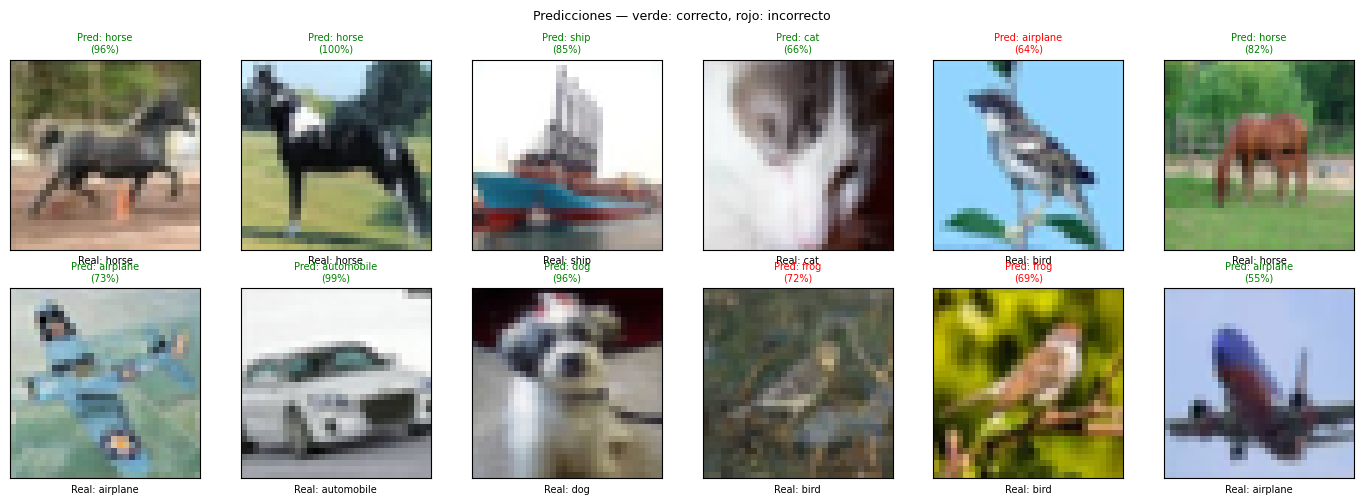

In [11]:
def predecir(imagen):
    """
    Predice la clase de una imagen.
    - imagen: array NumPy de shape (H, W, 3), valores en [0, 1] o [0, 255]
    Retorna: (clase_predicha, probabilidad, array_de_probabilidades)
    """
    # Redimensionar a 32x32 si es necesario
    img = tf.image.resize(imagen, [32, 32]).numpy()

    # Normalizar si los valores están en [0, 255]
    if img.max() > 1.0:
        img = img / 255.0

    # Agregar dimensión de batch: (1, 32, 32, 3)
    img_batch = np.expand_dims(img, axis=0)

    # Predicción
    probabilidades = modelo.predict(img_batch, verbose=0)[0]
    indice = np.argmax(probabilidades)

    return nombres_clases[indice], probabilidades[indice], probabilidades


# --- Prueba con imágenes del conjunto de verificación ---
n = 12
indices = np.random.choice(len(imagenes_verificacion), n, replace=False)

plt.figure(figsize=(14, 5))
for i, idx in enumerate(indices):
    clase_real      = nombres_clases[etiquetas_verificacion[idx][0]]
    clase_pred, prob, _ = predecir(imagenes_verificacion[idx])
    correcto = clase_real == clase_pred

    ax = plt.subplot(2, 6, i + 1)
    plt.imshow(imagenes_verificacion[idx])
    color = 'green' if correcto else 'red'
    plt.title(f'Pred: {clase_pred}\n({prob*100:.0f}%)', fontsize=7, color=color)
    plt.xlabel(f'Real: {clase_real}', fontsize=7)
    plt.xticks([])
    plt.yticks([])

plt.suptitle('Predicciones — verde: correcto, rojo: incorrecto', fontsize=9)
plt.tight_layout()
plt.show()

## 12. Subir una imagen propia para predecir

**Botón para cargar una imagen local** — el usuario puede subir cualquier imagen y el modelo la clasifica.

Seleccioná una imagen de tu computadora:


Saving 2323.png to 2323.png


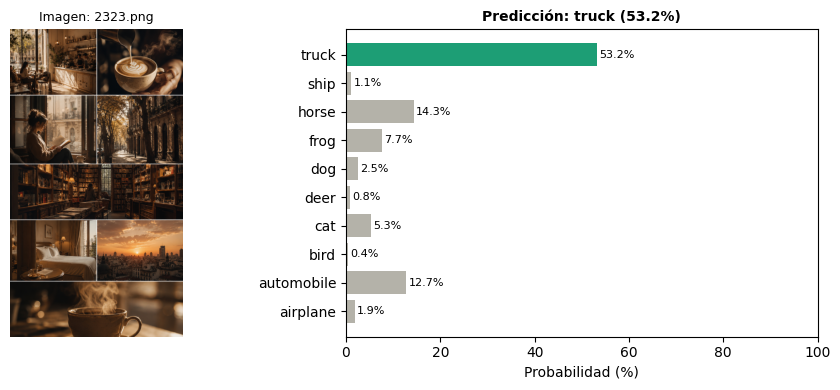


Archivo: 2323.png
Predicción: TRUCK (53.2% de confianza)


In [16]:
from google.colab import files
from PIL import Image
import io

print('Seleccioná una imagen de tu computadora:')
archivos = files.upload()

for nombre_archivo, contenido in archivos.items():
    imagen_pil = Image.open(io.BytesIO(contenido)).convert('RGB')
    imagen_np  = np.array(imagen_pil) / 255.0

    clase, prob, todas_probs = predecir(imagen_np)

    # Mostrar imagen y resultado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.imshow(imagen_pil)
    ax1.set_title(f'Imagen: {nombre_archivo}', fontsize=9)
    ax1.axis('off')

    # Barras de probabilidad
    colores = ['#1D9E75' if c == clase else '#B4B2A9' for c in nombres_clases]
    barras  = ax2.barh(nombres_clases, todas_probs * 100, color=colores)
    ax2.set_xlabel('Probabilidad (%)')
    ax2.set_title(f'Predicción: {clase} ({prob*100:.1f}%)', fontsize=10, fontweight='bold')
    ax2.set_xlim(0, 100)

    for barra, p in zip(barras, todas_probs):
        ax2.text(barra.get_width() + 0.5, barra.get_y() + barra.get_height()/2,
                 f'{p*100:.1f}%', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f'\nArchivo: {nombre_archivo}')
    print(f'Predicción: {clase.upper()} ({prob*100:.1f}% de confianza)')

## 13. Exportación para TensorFlow.js

Convertimos el modelo entrenado a formato TensorFlow.js y generamos un **HTML autónomo** que incluye el modelo embebido — un único archivo listo para usar en el browser sin servidor ni archivos adicionales.

El proceso:
1. Guardar el modelo como `.h5`
2. Convertir a formato TF.js (`model.json` + `.bin`)
3. Reescribir la topología en formato **Sequential compatible con TF.js 4.x** (Keras 3 genera un formato `Functional` con campos que TF.js no soporta)
4. Embeber modelo y pesos en base64 dentro del HTML final
5. Descargar el HTML — archivo único, autónomo, sin dependencias locales


In [ ]:
import os, json, base64
from google.colab import files

# ── 1. Guardar modelo Keras ───────────────────────────────────────────────
modelo.save('cifar10_modelo.h5')
print('✓ Modelo guardado como cifar10_modelo.h5')

# ── 2. Convertir a formato TensorFlow.js ─────────────────────────────────
os.makedirs('tfjs_model', exist_ok=True)
!tensorflowjs_converter --input_format=keras cifar10_modelo.h5 tfjs_model/
print('\n✓ Archivos TF.js generados:')
for f in os.listdir('tfjs_model/'):
    print(f'  {f}  ({os.path.getsize(f"tfjs_model/{f}") / 1024:.1f} KB)')

# ── 3. Leer y parchear la topología ──────────────────────────────────────
# Keras 3 exporta class_name='Functional' con campos incompatibles con TF.js 4.x.
# Se reescribe como Sequential limpio con los campos que TF.js entiende.
with open('tfjs_model/model.json', 'r') as f:
    model_json = json.load(f)

with open('tfjs_model/group1-shard1of1.bin', 'rb') as f:
    weights_b64 = base64.b64encode(f.read()).decode('ascii')

# Extraer pesos originales (solo los nombres/shapes, sin la topología rota)
weight_specs = model_json['weightsManifest'][0]['weights']

# Reconstruir topología Sequential compatible
def make_seq_layer(class_name, name, extra):
    base = {'name': name, 'trainable': True, 'dtype': 'float32'}
    base.update(extra)
    return {'class_name': class_name, 'config': base}

init_glorot = {'class_name': 'GlorotUniform', 'config': {'seed': None}}
init_zeros  = {'class_name': 'Zeros',         'config': {}}
dense_base  = {'use_bias': True,
               'kernel_initializer': init_glorot, 'bias_initializer': init_zeros,
               'kernel_regularizer': None, 'bias_regularizer': None,
               'kernel_constraint': None,  'bias_constraint': None}
conv_base   = {**dense_base,
               'strides': [1,1], 'padding': 'valid', 'data_format': 'channels_last',
               'dilation_rate': [1,1], 'groups': 1, 'activity_regularizer': None}

seq_layers = [
    make_seq_layer('Conv2D',       'conv2d_4',       {**conv_base, 'batch_input_shape': [None,32,32,3], 'filters': 32, 'kernel_size': [3,3], 'activation': 'relu'}),
    make_seq_layer('MaxPooling2D', 'max_pooling2d_4',{'pool_size': [2,2], 'strides': [2,2], 'padding': 'valid', 'data_format': 'channels_last'}),
    make_seq_layer('Conv2D',       'conv2d_5',       {**conv_base, 'filters': 64, 'kernel_size': [3,3], 'activation': 'relu'}),
    make_seq_layer('MaxPooling2D', 'max_pooling2d_5',{'pool_size': [2,2], 'strides': [2,2], 'padding': 'valid', 'data_format': 'channels_last'}),
    make_seq_layer('Flatten',      'flatten_2',      {'data_format': 'channels_last'}),
    make_seq_layer('Dense',        'dense_4',        {**dense_base, 'units': 128, 'activation': 'relu'}),
    make_seq_layer('Dropout',      'dropout_2',      {'rate': 0.4, 'noise_shape': None, 'seed': None}),
    make_seq_layer('Dense',        'dense_5',        {**dense_base, 'units': 10,  'activation': 'softmax'}),
]

model_json_fixed = {
    'format': 'layers-model',
    'generatedBy': 'keras',
    'convertedBy': 'TensorFlow.js Converter',
    'modelTopology': {
        'keras_version': '2.9.0',
        'backend': 'tensorflow',
        'model_config': {
            'class_name': 'Sequential',
            'config': {'name': 'sequential', 'trainable': True, 'layers': seq_layers}
        }
    },
    'weightsManifest': [{'paths': ['group1-shard1of1.bin'], 'weights': weight_specs}]
}

model_b64 = base64.b64encode(json.dumps(model_json_fixed, separators=(',',':')).encode()).decode('ascii')
print('✓ Topología parcheada (Functional → Sequential, compatible TF.js 4.x)')

# ── 4. Generar HTML autónomo ──────────────────────────────────────────────
html_template = open('clasificador_cifar10.html', 'r').read() if os.path.exists('clasificador_cifar10.html') else None

embed_script = f'const MODEL_JSON_B64 = "{model_b64}";\nconst WEIGHTS_B64 = "{weights_b64}";\n'

# HTML mínimo si no hay template
if html_template is None:
    print('⚠ No se encontró clasificador_cifar10.html — generando HTML básico')

with open('clasificador_cifar10_final.js', 'w') as f:
    f.write(embed_script)

print(f'✓ model_b64 length:   {len(model_b64):,}')
print(f'✓ weights_b64 length: {len(weights_b64):,}')

files.download('clasificador_cifar10_final.js')
print('\n✓ Descargado clasificador_cifar10_final.js')
print('  → Reemplazá modelo_embebido.js con este archivo (o usá clasificador_cifar10_final.html)')
